# Experiment 6 — Fine-tuning VGG16 on a Custom Image Dataset

**Objective:** Fine-tune a pre-trained VGG16 model on a custom image dataset and compare its accuracy with a CNN trained from scratch.

Dataset used: `custom_image_dataset/` with class folders such as `circle`, `square`, `triangle`, and `star`.

The notebook automatically detects the class folders and creates stratified train/validation/test splits.

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU devices: []


In [2]:
# Dataset configuration
# Keep this folder beside this notebook after extracting the ZIP file.
DATA_DIR = './custom_image_dataset'
IMG_SIZE = (96, 96)
VGG_SIZE = (224, 224)
BATCH_SIZE = 32
SCRATCH_EPOCHS = 8
VGG_HEAD_EPOCHS = 4
FINE_TUNE_EPOCHS = 3
TEST_SIZE = 0.20
VAL_SIZE = 0.20

print('Looking for:', os.path.abspath(DATA_DIR))
if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(
        f'Custom dataset not found at {os.path.abspath(DATA_DIR)}. '
        'Extract custom_image_dataset.zip into the same folder as this notebook.'
    )

Looking for: c:\5th sem\labs code\Deep learning\custom_image_dataset


In [3]:
# Automatically discover class folders and image files
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
class_names = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d)) and not d.startswith('.')
])

if len(class_names) < 2:
    raise ValueError('At least 2 class folders are required.')

paths, labels = [], []
for class_id, class_name in enumerate(class_names):
    class_dir = os.path.join(DATA_DIR, class_name)
    for root, _, files in os.walk(class_dir):
        for filename in files:
            if os.path.splitext(filename)[1].lower() in VALID_EXTENSIONS:
                paths.append(os.path.join(root, filename))
                labels.append(class_id)

paths = np.array(paths)
labels = np.array(labels)

if len(paths) < 20:
    raise ValueError(f'Only {len(paths)} images were found. Add more images.')

print('Classes:', class_names)
print('Total images:', len(paths))
for i, name in enumerate(class_names):
    print(f'{name}: {np.sum(labels == i)}')

Classes: ['circle', 'square', 'star', 'triangle']
Total images: 600
circle: 150
square: 150
star: 150
triangle: 150


In [4]:
# Stratified train / validation / test split
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels,
    test_size=TEST_SIZE + VAL_SIZE,
    random_state=SEED,
    stratify=labels
)

test_fraction_of_temp = TEST_SIZE / (TEST_SIZE + VAL_SIZE)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=test_fraction_of_temp,
    random_state=SEED,
    stratify=temp_labels
)

print(f'Train: {len(train_paths)} images')
print(f'Validation: {len(val_paths)} images')
print(f'Test: {len(test_paths)} images')

Train: 360 images
Validation: 120 images
Test: 120 images


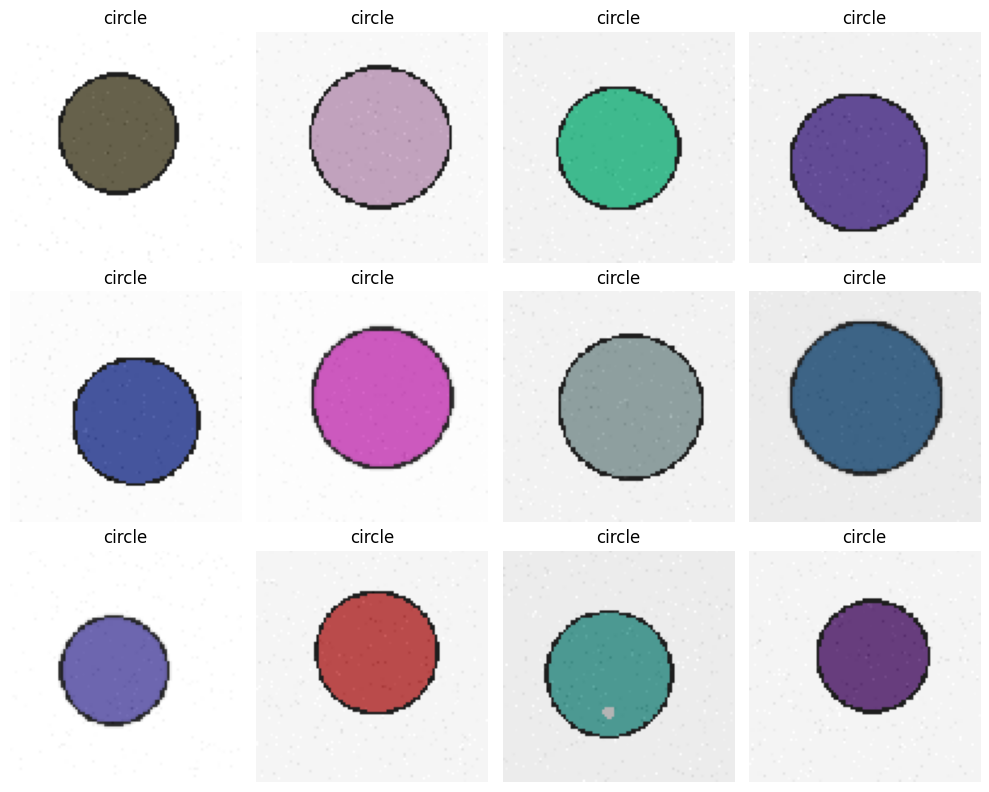

In [5]:
# Visualize sample images from the custom dataset
plt.figure(figsize=(10, 8))
for i in range(min(12, len(paths))):
    image = tf.keras.utils.load_img(paths[i], target_size=IMG_SIZE)
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(class_names[labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 1. CNN trained from scratch

In [6]:
def load_scratch_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_scratch_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED)
    return ds.map(load_scratch_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_scratch_dataset(train_paths, train_labels, True)
val_ds = make_scratch_dataset(val_paths, val_labels)
test_ds = make_scratch_dataset(test_paths, test_labels)

scratch_model = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.30),
    layers.Dense(len(class_names), activation='softmax')
])

scratch_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
scratch_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 96, 96, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
scratch_history = scratch_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=SCRATCH_EPOCHS,
    verbose=1
)

scratch_loss, scratch_acc = scratch_model.evaluate(test_ds, verbose=0)
print(f'CNN from scratch test accuracy: {scratch_acc * 100:.2f}%')

Epoch 1/8


C:\Users\himan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.2306 - loss: 1.3968 - val_accuracy: 0.2500 - val_loss: 1.3879
Epoch 2/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.2694 - loss: 1.3855 - val_accuracy: 0.2500 - val_loss: 1.3852
Epoch 3/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.2333 - loss: 1.3888 - val_accuracy: 0.2500 - val_loss: 1.3832
Epoch 4/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.3278 - loss: 1.3775 - val_accuracy: 0.2583 - val_loss: 1.3763
Epoch 5/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.3056 - loss: 1.3710 - val_accuracy: 0.2667 - val_loss: 1.3598
Epoch 6/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.3333 - loss: 1.3505 - val_accuracy: 0.2500 - val_loss: 1.3606
Epoch 7/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.2944 - loss: 1.3355 - val_accuracy: 0.4250 - val_loss: 1.2875
Epoch 8/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.3528 - loss: 1.3162 - val_accuracy: 0.4583 - val_loss: 1.2633
C

## 2. Pre-trained VGG16 — transfer learning

In [8]:
def load_vgg_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, VGG_SIZE)
    return image, label

def make_vgg_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED)
    return ds.map(load_vgg_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_vgg = make_vgg_dataset(train_paths, train_labels, True)
val_vgg = make_vgg_dataset(val_paths, val_labels)
test_vgg = make_vgg_dataset(test_paths, test_labels)

# Download ImageNet weights on the first run if they are not cached.
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(*VGG_SIZE, 3))
base_vgg.trainable = False

vgg_model = models.Sequential([
    layers.Input(shape=(*VGG_SIZE, 3)),
    layers.Lambda(tf.keras.applications.vgg16.preprocess_input),
    base_vgg,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.30),
    layers.Dense(len(class_names), activation='softmax')
])

vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,716,740 (56.14 MB)

 Trainable params: 2,052 (8.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
vgg_history = vgg_model.fit(
    train_vgg,
    validation_data=val_vgg,
    epochs=VGG_HEAD_EPOCHS,
    verbose=1
)

transfer_loss, transfer_acc = vgg_model.evaluate(test_vgg, verbose=0)
print(f'VGG16 transfer-learning test accuracy: {transfer_acc * 100:.2f}%')

Epoch 1/4
12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.2639 - loss: 3.3462 - val_accuracy: 0.6500 - val_loss: 0.9588
Epoch 2/4
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.5472 - loss: 1.3938 - val_accuracy: 0.9667 - val_loss: 0.1976
Epoch 3/4
12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.7861 - loss: 0.5524 - val_accuracy: 1.0000 - val_loss: 0.0490
Epoch 4/4
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.8778 - loss: 0.2854 - val_accuracy: 1.0000 - val_loss: 0.0177
VGG16 transfer-learning test accuracy: 100.00%


## 3. Fine-tune the last VGG16 layers

In [10]:
base_vgg.trainable = True

# Freeze most layers and fine-tune only the last 8 convolutional layers.
for layer in base_vgg.layers[:-8]:
    layer.trainable = False

vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_history = vgg_model.fit(
    train_vgg,
    validation_data=val_vgg,
    epochs=FINE_TUNE_EPOCHS,
    verbose=1
)

fine_loss, fine_acc = vgg_model.evaluate(test_vgg, verbose=0)
print(f'Fine-tuned VGG16 test accuracy: {fine_acc * 100:.2f}%')

Epoch 1/3
12/12 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.9722 - loss: 0.0554 - val_accuracy: 1.0000 - val_loss: 5.4565e-06
Epoch 2/3
12/12 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 1.0000 - loss: 9.5275e-04 - val_accuracy: 1.0000 - val_loss: 2.9206e-07
Epoch 3/3
12/12 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 1.0000 - loss: 1.0711e-04 - val_accuracy: 1.0000 - val_loss: 9.9341e-08
Fine-tuned VGG16 test accuracy: 100.00%


## 4. Compare accuracy

CNN From Scratch: 45.00%
VGG16 Transfer Learning: 100.00%
VGG16 Fine-Tuned: 100.00%


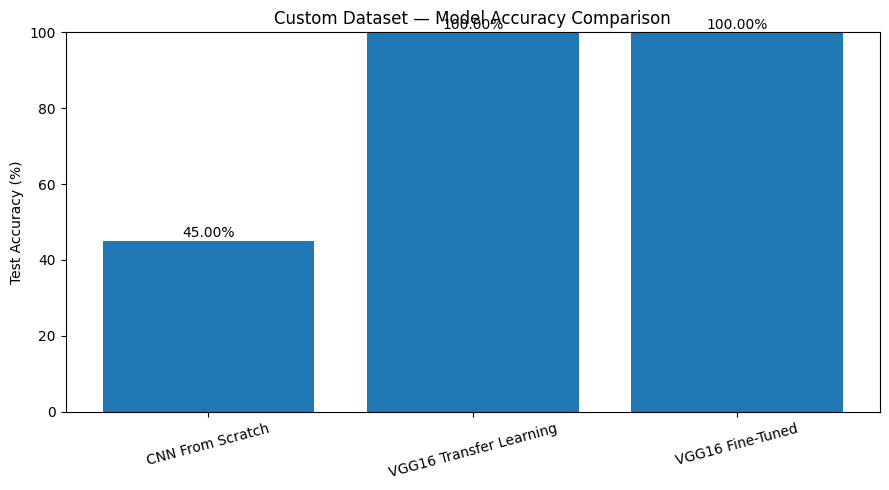

In [11]:
results = {
    'CNN From Scratch': scratch_acc * 100,
    'VGG16 Transfer Learning': transfer_acc * 100,
    'VGG16 Fine-Tuned': fine_acc * 100,
}

for name, accuracy in results.items():
    print(f'{name}: {accuracy:.2f}%')

plt.figure(figsize=(9, 5))
bars = plt.bar(results.keys(), results.values())
plt.ylabel('Test Accuracy (%)')
plt.title('Custom Dataset — Model Accuracy Comparison')
plt.ylim(0, 100)
plt.xticks(rotation=15)
for bar, value in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, value + 1, f'{value:.2f}%', ha='center')
plt.tight_layout()
plt.show()

## 5. Confusion matrix and classification report — Fine-tuned VGG16

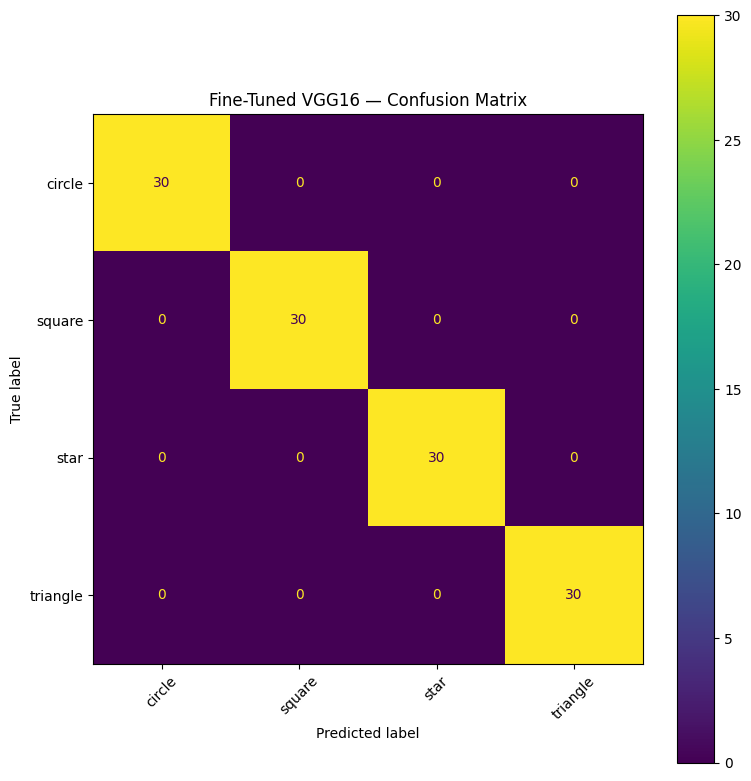

              precision    recall  f1-score   support

      circle       1.00      1.00      1.00        30
      square       1.00      1.00      1.00        30
        star       1.00      1.00      1.00        30
    triangle       1.00      1.00      1.00        30

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



In [ ]:
y_true, y_pred = [], []
for images, batch_labels in test_vgg:
    probabilities = vgg_model.predict(images, verbose=0)
    y_true.extend(batch_labels.numpy())
    y_pred.extend(np.argmax(probabilities, axis=1))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labe ls=class_names).plot(
    ax=ax, xticks_rotation=45, values_format='d'
)
plt.title('Fine-Tuned VGG16 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

## Final observation

This experiment compares three settings on the **same custom dataset**:
1. CNN trained from scratch.
2. VGG16 with ImageNet feature extractor frozen (transfer learning).
3. VGG16 with its final layers fine-tuned on the custom classes.

Use the measured test accuracies above for the final comparison. Do not assume that fine-tuning will always be higher; the dataset size and class difficulty determine the actual result.